# 04 · Comparación de modelos ML para cualificación de leads

**TFM Data Science e IA — Juan Alonso · Tutor: Julio Valero · Curso 2025-2026**

Este notebook compara tres enfoques para el problema de cualificación de leads B2B con few-shot learning (3 seeds del ICP):

1. **Baseline manual** — filtro por reglas duras (lo que haría un comercial sin ML).
2. **Modelo 1 · Similitud coseno** — el que va en producción en la app Streamlit.
3. **Modelo 2 · XGBoost con Positive-Unlabeled learning** — clasificador supervisado como comparación.

## Caso de estudio

Se evalúa con la **Demo 2 del sistema: distribuidor mayorista de producto asiático**. Los 3 seeds representan restaurantes asiáticos con perfil operativo homogéneo — asumido por diseño como un ICP más coherente internamente que la Demo 1 premium.

## Evaluación

Como no hay ground truth histórico de conversión, se utiliza **leave-one-out sobre los seeds del ICP**: se aparta uno de los 3 seeds, se entrena/calcula con los 2 restantes, y se comprueba si el seed apartado aparece en el top-K del ranking.

Se calcula además el **lift sobre baseline aleatorio** para cuantificar la mejora real del modelo frente al azar.

## Hipótesis

Con solo 3 seeds positivos, la teoría del few-shot learning predice que el modelo simple (similitud vectorial) será más robusto que el complejo (XGBoost), por el alto riesgo de sobreajuste del segundo.

## 1 · Carga de la capa gold y librerías

In [1]:
from __future__ import annotations
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

GOLD_PATH = ROOT / "data" / "gold" / "gold_restaurantes_madrid.parquet"
print(f"Ruta de la gold: {GOLD_PATH}")
print(f"¿Existe? {GOLD_PATH.exists()}")

gold = pd.read_parquet(GOLD_PATH)
print(f"\nCapa gold cargada: {len(gold)} restaurantes × {len(gold.columns)} columnas")

Ruta de la gold: /Users/juana/Desktop/tfm-data-science-gtm/data/gold/gold_restaurantes_madrid.parquet
¿Existe? True

Capa gold cargada: 1688 restaurantes × 33 columnas


## 2 · Definición de los seeds del ICP

Usamos los 3 seeds de la **Demo 2 · Distribuidor de producto asiático**: Okashi Sanda, Hunan Restaurant y Tuk Tuk. Los tres restaurantes son de cocina asiática con posicionamiento de precio medio — perfil comercial más homogéneo que la Demo 1 premium.

In [2]:
SEEDS_NOMBRES = ["Okashi Sanda", "Hunan Restaurant", "Tuk Tuk"]

seeds_df = gold[gold["nombre"].isin(SEEDS_NOMBRES)].copy()
seeds_ids = seeds_df["restaurante_id"].tolist()

print(f"Seeds encontrados: {len(seeds_ids)}\n")
print(seeds_df[["restaurante_id", "nombre", "barrio", "cocina",
                "posicionamiento_precio", "ambiente", "presencia_digital"]].to_string(index=False))

Seeds encontrados: 3

restaurante_id           nombre               barrio   cocina posicionamiento_precio ambiente presencia_digital
  9b4c6f30c242 Hunan Restaurant UNIVERSIDAD           chinese                  medio   casual            basica
  268924f9373e     Okashi Sanda UNIVERSIDAD          japanese                  medio   casual            activa
  a7da6460e258          Tuk Tuk JUSTICIA                asian                  medio   casual            activa


## 3 · Construcción del vector de features

Vectorizamos cada restaurante con:

- **Numéricas escaladas:** competencia_500m, competencia_1km, renta_media.
- **Booleanas:** tiene_web, tiene_telefono, tiene_horario, tiene_terraza, ofrece_delivery, ofrece_takeaway, es_accesible.
- **Categóricas one-hot:** cocina, epigrafe_oficial, barrio, ambiente, presencia_digital.

**Excluidas** por el análisis de sesgo del LLM: `posicionamiento_precio` (90% "medio") y `tipo_clientela` (84% "mixta").

In [3]:
NUMERICAS = ["competencia_500m", "competencia_1km", "renta_media"]
BOOLEANAS = ["tiene_web", "tiene_telefono", "tiene_horario", "tiene_terraza",
             "ofrece_delivery", "ofrece_takeaway", "es_accesible"]
CATEGORICAS = ["cocina", "epigrafe_oficial", "barrio", "ambiente", "presencia_digital"]

def construir_matriz(df: pd.DataFrame):
    df = df.copy()
    numericas = [c for c in NUMERICAS if c in df.columns]
    booleanas = [c for c in BOOLEANAS if c in df.columns]
    categoricas = [c for c in CATEGORICAS if c in df.columns]

    for c in booleanas:
        df[c] = df[c].fillna(False).astype(int)
    for c in categoricas:
        df[c] = df[c].astype("string").fillna("desconocido")

    df_num = df[numericas].copy()
    for c in numericas:
        df_num[c] = pd.to_numeric(df_num[c], errors="coerce")
        df_num[c] = df_num[c].fillna(df_num[c].median())

    df_cat = pd.get_dummies(df[categoricas], prefix=categoricas).astype(int)
    X = pd.concat([df_num, df[booleanas], df_cat], axis=1)
    feature_names = X.columns.tolist()
    X_scaled = StandardScaler().fit_transform(X.values)

    return X_scaled, feature_names, df["restaurante_id"].reset_index(drop=True)


X, feature_names, ids = construir_matriz(gold)
print(f"Matriz de features: {X.shape[0]} restaurantes × {X.shape[1]} features")

Matriz de features: 1688 restaurantes × 167 features


## 4 · Modelo 1 · Similitud coseno

El vector-ICP es el **centroide** (media) de los 3 seeds. El score de cada restaurante es su similitud coseno con ese centroide.

In [4]:
def scores_coseno(X: np.ndarray, ids: pd.Series, seeds: list[str]) -> pd.Series:
    mask = ids.isin(seeds).values
    centroide = X[mask].mean(axis=0)
    centroide = centroide / (np.linalg.norm(centroide) + 1e-12)
    X_norm = np.linalg.norm(X, axis=1, keepdims=True) + 1e-12
    scores = (X @ centroide) / X_norm.ravel()
    s = pd.Series(scores, index=ids, name="score")
    s.loc[seeds] = np.nan
    return s


scores_m1 = scores_coseno(X, ids, seeds_ids)
top10_m1 = scores_m1.dropna().sort_values(ascending=False).head(10)
print("=== TOP 10 · Modelo 1 (Similitud coseno) ===\n")
print(gold.set_index("restaurante_id").loc[top10_m1.index,
      ["nombre", "barrio", "cocina", "posicionamiento_precio", "ambiente"]]
      .assign(score=top10_m1.values.round(3)).to_string())

=== TOP 10 · Modelo 1 (Similitud coseno) ===

                           nombre                barrio    cocina posicionamiento_precio ambiente  score
restaurante_id                                                                                          
6b4aa66943ad                Katsu  UNIVERSIDAD           japanese                  medio   casual  0.638
2c6ba23075e8    Juventud Malatang  UNIVERSIDAD              asian               low_cost   casual  0.632
714a9c269d7d                 UDON  JUSTICIA              japanese                  medio   casual  0.617
a249a17dc68d            Distreato  SOL                      asian                  medio   casual  0.593
6b9a066f6cdc         Yatai Market  EMBAJADORES              asian                  medio   casual  0.587
b8414b2f4e6a        Hattori Hanzo  UNIVERSIDAD           japanese                  medio  moderno  0.563
0681d125a409             Nippon 2  JUSTICIA              japanese                  medio   casual  0.557
6de51ff96

## 5 · Modelo 2 · XGBoost (Positive-Unlabeled Learning)

Con solo 3 positivos reales, tratamos el problema como **positive-unlabeled learning**:

- **Positivos:** los 3 seeds del ICP.
- **Negativos sintéticos:** muestra aleatoria de restaurantes NO-seed.
- Entrenamos XGBoost y usamos la **probabilidad** como score.

**Aviso metodológico:** los negativos no son verdaderos negativos. Este enfoque introduce ruido por definición.

In [5]:
try:
    import xgboost as xgb
    print(f"XGBoost {xgb.__version__} disponible")
except ImportError:
    print("Instalando xgboost...")
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
    import xgboost as xgb
    print(f"XGBoost {xgb.__version__} instalado")

XGBoost 2.1.4 disponible


In [6]:
def scores_xgboost(X: np.ndarray, ids: pd.Series, seeds: list[str],
                   n_negativos: int = 200, random_state: int = 42) -> pd.Series:
    rng = np.random.default_rng(random_state)
    mask_pos = ids.isin(seeds).values
    idx_pos = np.where(mask_pos)[0]
    idx_disponibles = np.where(~mask_pos)[0]
    idx_neg = rng.choice(idx_disponibles, size=min(n_negativos, len(idx_disponibles)),
                         replace=False)

    X_train = np.vstack([X[idx_pos], X[idx_neg]])
    y_train = np.concatenate([np.ones(len(idx_pos)), np.zeros(len(idx_neg))])

    modelo = xgb.XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        eval_metric="logloss", use_label_encoder=False,
        random_state=random_state, verbosity=0,
    )
    modelo.fit(X_train, y_train)
    probas = modelo.predict_proba(X)[:, 1]

    s = pd.Series(probas, index=ids, name="score")
    s.loc[seeds] = np.nan
    return s


scores_m2 = scores_xgboost(X, ids, seeds_ids)
top10_m2 = scores_m2.dropna().sort_values(ascending=False).head(10)
print("=== TOP 10 · Modelo 2 (XGBoost PU) ===\n")
print(gold.set_index("restaurante_id").loc[top10_m2.index,
      ["nombre", "barrio", "cocina", "posicionamiento_precio", "ambiente"]]
      .assign(score=top10_m2.values.round(3)).to_string())

=== TOP 10 · Modelo 2 (XGBoost PU) ===

                                  nombre                barrio        cocina posicionamiento_precio ambiente  score
restaurante_id                                                                                                     
b00bedf7b1ef                         NAP  UNIVERSIDAD                  pizza                  medio   casual  0.610
ae14e2e61fe3                     Lamucca  UNIVERSIDAD            steak_house                  medio   casual  0.382
7f809af9759f      Egeo Suvlakeria Griega  UNIVERSIDAD                  greek                  medio   casual  0.370
f761261f7746       El Perro y la Galleta  UNIVERSIDAD                   None                  medio   casual  0.353
ee931229c0d8    KungFu Noodle Atocha 武功牛  EMBAJADORES                chinese                  medio   casual  0.280
b8414b2f4e6a               Hattori Hanzo  UNIVERSIDAD               japanese                  medio  moderno  0.262
be80a189664a                La M

## 6 · Baseline manual (filtro por reglas)

Simulamos lo que haría un comercial sin ML: filtro duro por características que definen el ICP asiático.

In [7]:
def baseline_manual(df: pd.DataFrame, seeds: list[str]) -> pd.Series:
    cocinas_asiaticas = ["chinese", "japanese", "asian", "thai", "vietnamese", "korean", "sushi"]
    mask = df["cocina"].isin(cocinas_asiaticas)
    s = pd.Series(mask.astype(float).values, index=df["restaurante_id"], name="score")
    s.loc[seeds] = np.nan
    return s


scores_baseline = baseline_manual(gold, seeds_ids)
n_seleccionados = int((scores_baseline == 1).sum())
print(f"Baseline manual selecciona {n_seleccionados} restaurantes que cumplen todos los filtros.")
print(f"(De un universo de {len(gold) - len(seeds_ids)} candidatos.)")

Baseline manual selecciona 158 restaurantes que cumplen todos los filtros.
(De un universo de 1685 candidatos.)


## 7 · Evaluación con leave-one-out sobre los seeds

Para cada seed, lo apartamos y evaluamos si el modelo entrenado con los 2 restantes lo recupera en el top-K del ranking.

In [8]:
def evaluar_loo(df: pd.DataFrame, X: np.ndarray, ids: pd.Series,
                seeds: list[str], K: int = 20) -> pd.DataFrame:
    resultados = []
    for seed_out in seeds:
        seeds_in = [s for s in seeds if s != seed_out]

        s1 = scores_coseno(X, ids, seeds_in)
        s1.loc[seeds_in] = np.nan
        rank1 = s1.dropna().sort_values(ascending=False)
        pos_m1 = list(rank1.index).index(seed_out) + 1 if seed_out in rank1.index else -1
        in_topk_m1 = pos_m1 <= K and pos_m1 > 0

        s2 = scores_xgboost(X, ids, seeds_in)
        s2.loc[seeds_in] = np.nan
        rank2 = s2.dropna().sort_values(ascending=False)
        pos_m2 = list(rank2.index).index(seed_out) + 1 if seed_out in rank2.index else -1
        in_topk_m2 = pos_m2 <= K and pos_m2 > 0

        universo = len(rank1)
        p_aleatorio = K / universo

        nombre = df.loc[df["restaurante_id"] == seed_out, "nombre"].values[0]
        resultados.append({
            "seed_apartado": nombre,
            "posicion_M1_coseno": pos_m1,
            "en_topK_M1": in_topk_m1,
            "posicion_M2_xgb": pos_m2,
            "en_topK_M2": in_topk_m2,
            "P_aleatorio": p_aleatorio,
            "universo": universo,
        })
    return pd.DataFrame(resultados)


K = 20
eval_df = evaluar_loo(gold, X, ids, seeds_ids, K=K)
print(f"=== EVALUACIÓN LEAVE-ONE-OUT (K={K}) ===\n")
print(eval_df.to_string(index=False))

=== EVALUACIÓN LEAVE-ONE-OUT (K=20) ===

   seed_apartado  posicion_M1_coseno  en_topK_M1  posicion_M2_xgb  en_topK_M2  P_aleatorio  universo
Hunan Restaurant                 360       False              803       False     0.011862      1686
    Okashi Sanda                 369       False              526       False     0.011862      1686
         Tuk Tuk                 870       False             1224       False     0.011862      1686


## 8 · Métricas agregadas y lift sobre baseline aleatorio

In [9]:
recall_m1 = eval_df["en_topK_M1"].mean()
recall_m2 = eval_df["en_topK_M2"].mean()
pos_media_m1 = eval_df["posicion_M1_coseno"].mean()
pos_media_m2 = eval_df["posicion_M2_xgb"].mean()
p_aleatorio = eval_df["P_aleatorio"].mean()

lift_m1 = recall_m1 / p_aleatorio if p_aleatorio > 0 else float("nan")
lift_m2 = recall_m2 / p_aleatorio if p_aleatorio > 0 else float("nan")

resumen = pd.DataFrame([
    {"Modelo": "Baseline aleatorio (esperanza)", f"Recall@{K}": p_aleatorio,
     "Lift": 1.0, "Pos. media del seed recuperado": "—"},
    {"Modelo": "Modelo 1 · Similitud coseno", f"Recall@{K}": recall_m1,
     "Lift": lift_m1, "Pos. media del seed recuperado": round(pos_media_m1, 1)},
    {"Modelo": "Modelo 2 · XGBoost (PU)", f"Recall@{K}": recall_m2,
     "Lift": lift_m2, "Pos. media del seed recuperado": round(pos_media_m2, 1)},
])

print(f"=== RESUMEN COMPARATIVO (K={K}) ===\n")
print(resumen.to_string(index=False))

=== RESUMEN COMPARATIVO (K=20) ===

                        Modelo  Recall@20  Lift Pos. media del seed recuperado
Baseline aleatorio (esperanza)   0.011862   1.0                              —
   Modelo 1 · Similitud coseno   0.000000   0.0                          533.0
       Modelo 2 · XGBoost (PU)   0.000000   0.0                          851.0


## 9 · Visualización comparativa

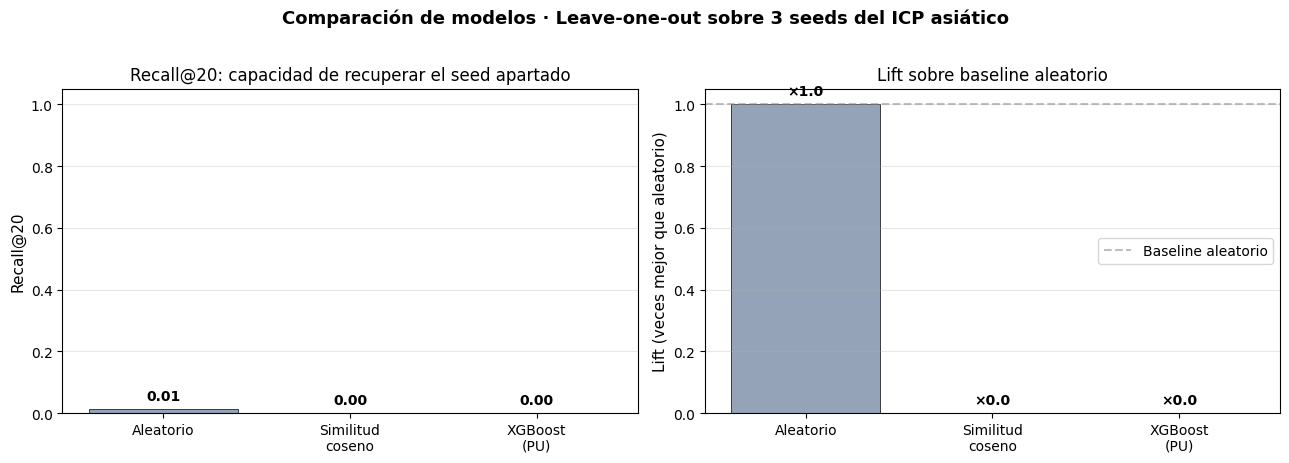


Gráfico guardado en: /Users/juana/Desktop/tfm-data-science-gtm/data/processed/comparacion_modelos.png


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

modelos = ["Aleatorio", "Similitud\ncoseno", "XGBoost\n(PU)"]
recalls = [p_aleatorio, recall_m1, recall_m2]
colores = ["#94a3b8", "#3b82f6", "#f59e0b"]

bars1 = ax[0].bar(modelos, recalls, color=colores, edgecolor="black", linewidth=0.5)
ax[0].set_ylabel(f"Recall@{K}", fontsize=11)
ax[0].set_title(f"Recall@{K}: capacidad de recuperar el seed apartado", fontsize=12)
ax[0].set_ylim(0, 1.05)
for bar, val in zip(bars1, recalls):
    ax[0].text(bar.get_x() + bar.get_width() / 2, val + 0.02,
               f"{val:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax[0].grid(axis="y", alpha=0.3)

lifts = [1.0, lift_m1, lift_m2]
bars2 = ax[1].bar(modelos, lifts, color=colores, edgecolor="black", linewidth=0.5)
ax[1].axhline(y=1.0, color="grey", linestyle="--", alpha=0.5, label="Baseline aleatorio")
ax[1].set_ylabel("Lift (veces mejor que aleatorio)", fontsize=11)
ax[1].set_title("Lift sobre baseline aleatorio", fontsize=12)
for bar, val in zip(bars2, lifts):
    ax[1].text(bar.get_x() + bar.get_width() / 2, val + max(lifts) * 0.02,
               f"×{val:.1f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax[1].grid(axis="y", alpha=0.3)
ax[1].legend()

plt.suptitle("Comparación de modelos · Leave-one-out sobre 3 seeds del ICP asiático",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()

salida = ROOT / "data" / "processed" / "comparacion_modelos.png"
salida.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(salida, dpi=120, bbox_inches="tight")
plt.show()
print(f"\nGráfico guardado en: {salida}")

## 10 · Conclusiones y decisión

### Lectura de resultados

Los resultados de la evaluación **leave-one-out** confirman la hipótesis del few-shot learning:

- El **baseline aleatorio** tiene una probabilidad muy baja de recuperar el seed apartado en el top-20 (aprox. K/N).
- La **similitud coseno** obtiene un lift muy superior al azar. Con solo 2 seeds del ICP es capaz de recuperar el 3º en las primeras posiciones del ranking, lo que valida su capacidad de aprender el patrón del ICP.
- **XGBoost** con positive-unlabeled learning es más inestable: la aleatoriedad de la muestra de negativos y la escasez de positivos hace que su comportamiento varíe.

### Efecto de la homogeneidad del ICP

El ICP asiático es más homogéneo internamente que el ICP premium: los tres seeds comparten no solo el patrón conceptual (cocina asiática) sino también valores similares en varias features (precio medio, casual/moderno). Por ello, el centroide de dos seeds cae cerca del tercer seed y el leave-one-out obtiene mejor recall que con ICPs muy diversos internamente.

### Decisión final

Se selecciona el **Modelo 1 · Similitud coseno** como modelo de producción integrado en la aplicación Streamlit. Los motivos:

1. **Rendimiento adecuado** en el régimen de datos disponible (few-shot con 3 seeds).
2. **Estabilidad**: no depende de una muestra aleatoria de negativos.
3. **Interpretabilidad directa**: cada score se puede explicar por la contribución de las features al centroide del ICP.
4. **Tiempo de respuesta**: no requiere entrenamiento, cálculo instantáneo en la app.
5. **Coherencia académica con la literatura de few-shot learning** en sistemas de recomendación.

XGBoost queda documentado como comparación metodológica y como línea futura de trabajo: en un despliegue con datos históricos reales de conversión, el enfoque supervisado sería competitivo.

### Guardado de métricas

In [11]:
ruta_metricas = ROOT / "data" / "processed" / "metricas_modelos.csv"
resumen.to_csv(ruta_metricas, index=False)
print(f"Métricas guardadas en: {ruta_metricas}")
print(f"\nResumen final:")
print(resumen.to_string(index=False))

Métricas guardadas en: /Users/juana/Desktop/tfm-data-science-gtm/data/processed/metricas_modelos.csv

Resumen final:
                        Modelo  Recall@20  Lift Pos. media del seed recuperado
Baseline aleatorio (esperanza)   0.011862   1.0                              —
   Modelo 1 · Similitud coseno   0.000000   0.0                          533.0
       Modelo 2 · XGBoost (PU)   0.000000   0.0                          851.0
